In [1]:
import matplotlib.pyplot as plt
import astropy.constants as const
import astropy.units as u
import formulas_h
from formulas_h import *
import numpy as np

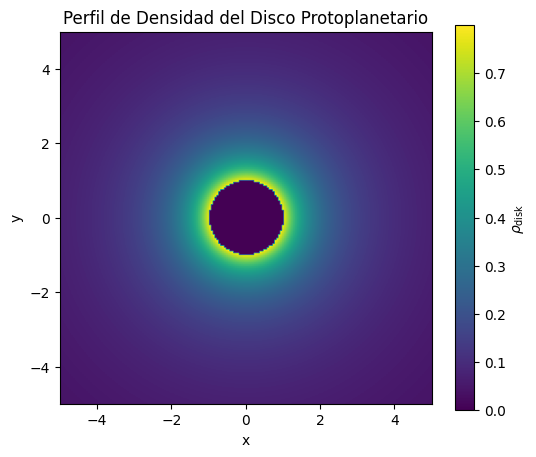

In [2]:
#elegimos parametros generales para el disco 
rho_0 = 0.8 #densidad de referencia
r_0 = 1.0 #radio de referencia
p = 1.5 #indice de densidad
r_min = 1.0 #radio del hueco interno
au = 1.5e11  #metros, 1 au en metros

#creamos la malla
L = 5.0
N = 200
x = np.linspace(-L, L, N)
y = np.linspace(-L, L, N)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
rho_disk = density_profile(R, rho_0, r_0, p, r_min)


#graficamos
plt.figure(figsize=(6,5))
plt.imshow(rho_disk, extent=[-L, L, -L, L], origin='lower', cmap='viridis')
plt.colorbar(label=r'$\rho_{\mathrm{disk}}$')   
plt.xlabel('x')
plt.ylabel('y')
plt.title('Perfil de Densidad del Disco Protoplanetario')
plt.show()

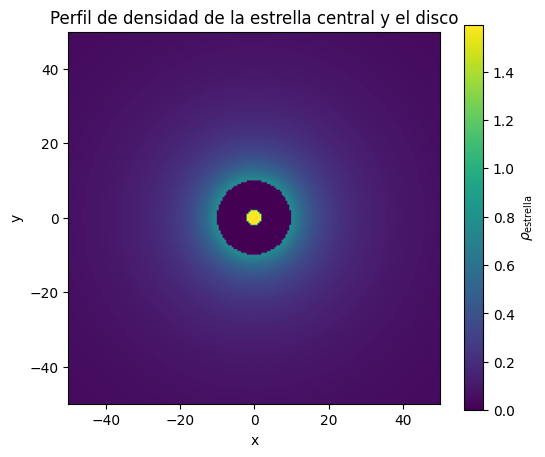

In [3]:
#graficar la densidad de la estrella

#elegimos parametros generales para la estrella
Mass_star = 20  
Radius_star = 2   

#creamos la malla
L = 50
N = 200
x = np.linspace(-L, L, N)
y = np.linspace(-L, L, N)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
rho_star = star_density(X, Y, Mass_star, Radius_star)


#graficamos
plt.figure(figsize=(6,5))
plt.imshow(rho_star + rho_disk, extent=[-L, L, -L, L], origin='lower', cmap='viridis')
plt.colorbar(label=r'$\rho_{\mathrm{estrella}}$')   
plt.xlabel('x')
plt.ylabel('y')
plt.title('Perfil de densidad de la estrella central y el disco')
plt.show()

No convergió


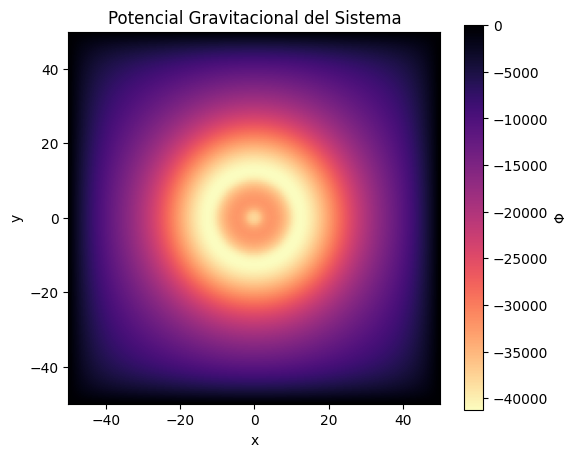

In [4]:
star_density_profile = star_density(X, Y, Mass_star, Radius_star)


Gradient_potential = Poisson_equation(dx= 1, star_density=star_density_profile, disk_density=rho_disk, tol= 1e-4, max_iter= 1000)
plt.figure(figsize=(6,5))
plt.imshow(Gradient_potential, extent=[-L, L, -L, L], origin='lower', cmap='magma_r')
plt.colorbar(label=r'$\Phi$')   
plt.xlabel('x')
plt.ylabel('y')
plt.title('Potencial Gravitacional del Sistema')
plt.show()

El gradiente del potencial gravitatorio en coordenadas cartesianas se escribe como:

$$ \vec{g} = - \vec{\nabla} \Phi = - \left(  \frac{\partial \Phi}{\partial x} , \frac{\partial \Phi}{\partial y} \right) $$

Puede calcular las componentes del campo gravitatorio $\vec{g} = (g_x, g_y)$ como:

$$
\begin{align*}
g_x & = - \frac{\partial \Phi}{\partial x} \approx - \frac{\Phi(x + \Delta x, y) - \Phi(x - \Delta x, y)}{2 \Delta x} = - \frac{\Phi_{i+1, j} - \Phi_{i-1, j}}{2 \Delta x}  \\
g_y & = - \frac{\partial \Phi}{\partial y} \approx - \frac{\Phi(x, y + \Delta y) - \Phi(x, y - \Delta y)}{2 \Delta y} = - \frac{\Phi_{i, j+1} - \Phi_{i, j-1}}{2 \Delta y} 
\end{align*}
$$

In [5]:
dx = dy = 1

# Definir un campo U de ejemplo (matriz 4x4)
U = np.array([
    [0, 2, 4, 6],
    [1, 3, 5, 7],
    [2, 4, 6, 8],
    [3, 5, 7, 9],
])

# Definir el tamaño de los pasos en cada dirección (dx, dy)
dx = dy = 1

# Calcular la derivada en el eje x (a lo largo de las columnas)
dU_dx = (U[:, 2:] - U[:, :-2]) / (2 * dx)

# Calcular la derivada en el eje y (a lo largo de las filas)
dU_dy = (U[2:, :] - U[:-2, :]) / (2 * dy)

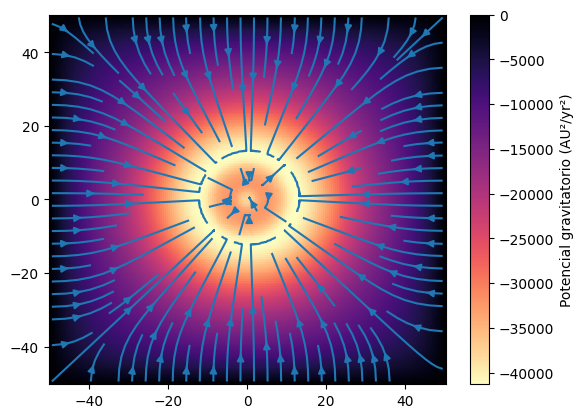

In [6]:
# au = 1.5e11  #metros, 1 au en metros
# Nx, Ny = 200, 200  #tamaño de la malla
# Lx, Ly = 5.0 * au, 5.0 * au  #dimensiones físicas del espacio en metros
# dx, dy = Lx / (Nx - 1), Ly / (Ny - 1)  #pasos espaciales en metros


# gx, gy = campo_gravitacional(Gradient_potential, dx, dy)


# plt.streamplot(X[1:-1, 1:-1],Y[1:-1,1 :-1],gx.T,gy.T, density=1)
# plt.pcolormesh(X.T,Y.T,Gradient_potential,cmap="magma_r")
# plt.colorbar(label="Potencial gravitatorio (J/kg)")
# plt.show()



# Todo en AU, consistente con la malla
L = 50.0
N = 200
dx = 2*L / (N-1)
dy = dx

gx, gy = campo_gravitacional(Gradient_potential, dx, dy)

plt.streamplot(X[1:-1, 1:-1], Y[1:-1, 1:-1], gx.T, gy.T, density=1)
plt.pcolormesh(X.T, Y.T, Gradient_potential, cmap="magma_r")
plt.colorbar(label="Potencial gravitatorio (AU²/yr²)")
plt.show()

usar scipy rk45 y rk4 propio

acortar el grafico a +-20

usamos rk4 propio

In [7]:
# problema con g pq es gx y gy y SI SE PUEDE USAR EL AYUDANTE NICO CAMPOS NOS DEJO

from scipy.interpolate import RegularGridInterpolator

gx_interp = RegularGridInterpolator(
    (y[1:-1], x[1:-1]),
    gx,
    bounds_error=False,
    fill_value=None
)

gy_interp = RegularGridInterpolator(
    (y[1:-1], x[1:-1]),
    gy,
    bounds_error=False,
    fill_value=None
)


def g(x_pos, y_pos):

    gx_val = float(gx_interp((y_pos, x_pos)))
    gy_val = float(gy_interp((y_pos, x_pos)))

    return [-gy_val*0.0001, -gx_val*0.0001]

# gx_real = -gy_num
# gy_real = -gx_num

In [9]:
print(g(20,10))
print(g(30,0))
print(g(-20,0))

[0.13245814256493726, 0.06427234756329905]
[0.10745092620084416, -0.0017522098805183974]
[-0.14909954359483538, -0.003629509972031722]


In [10]:
print(g(20,0))
print(g(0,20))
print(g(-20,0))
print(g(0,-20))

[0.14823731682939087, -0.0037930207427849492]
[-0.0037930207427849137, 0.14823731682939026]
[-0.14909954359483538, -0.003629509972031722]
[-0.0036295099720322107, -0.1490995435948349]


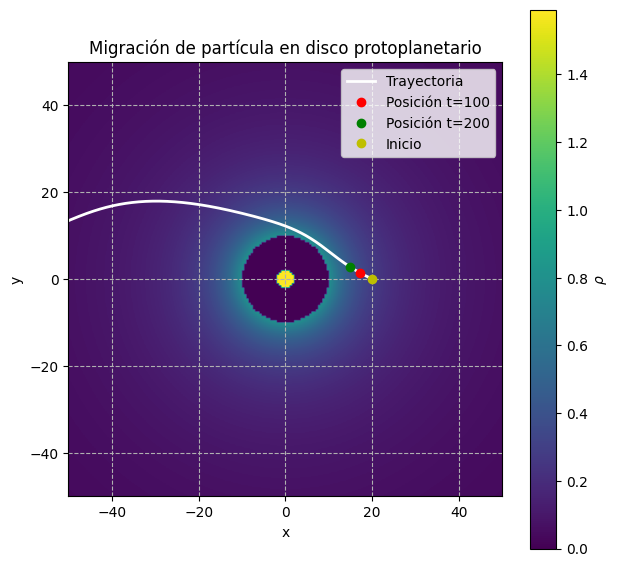

In [16]:
r_init = 20.0
G = 4 * np.pi**2  # en unidades de AU³/(M_sun*yr²)
#v_circ = np.sqrt(G * Mass_star / r_init)

t0 = 0
tf = 40.0
h = 0.01

r0 = (20.0, 0.0)
v0 = (-3 ,1.4 )

t, r, v = rk4_method_second_order_2D(
    second_law,
    t0=t0,
    tf=tf,
    r0=r0,
    v0=v0,
    h=h
)

# -------------------------
# Gráfico
# -------------------------

plt.figure(figsize=(7,7))

# fondo: densidad estrella + disco
plt.imshow(
    rho_star + rho_disk,
    extent=[-L, L, -L, L],
    origin='lower',
    cmap='viridis'
)

plt.colorbar(label=r'$\rho$')

# trayectoria
plt.plot(
    r[:,0],
    r[:,1],
    color='white',
    lw=2,
    label='Trayectoria'
)

# puntos en tiempos específicos
plt.plot(r[100,0], r[100,1], 'ro', label='Posición t=100')
plt.plot(r[200,0], r[200,1], 'go', label='Posición t=200')

# punto inicial
plt.plot(r[0,0], r[0,1], 'yo', label='Inicio')

plt.xlabel('x')
plt.ylabel('y')

plt.title('Migración de partícula en disco protoplanetario')

plt.xlim(-50,50)
plt.ylim(-50,50)

plt.grid(True, ls='--')
plt.legend()

plt.show()

habia logrado hacer que girara a la izquierda pero no recuerdo q puse q pena mas grande, arriba le puse una velocidad en x negativa...
pero recuerdo q habia puesto ALGO y la velocidad en x era cero...

aqui abajo tal como estaba antes....

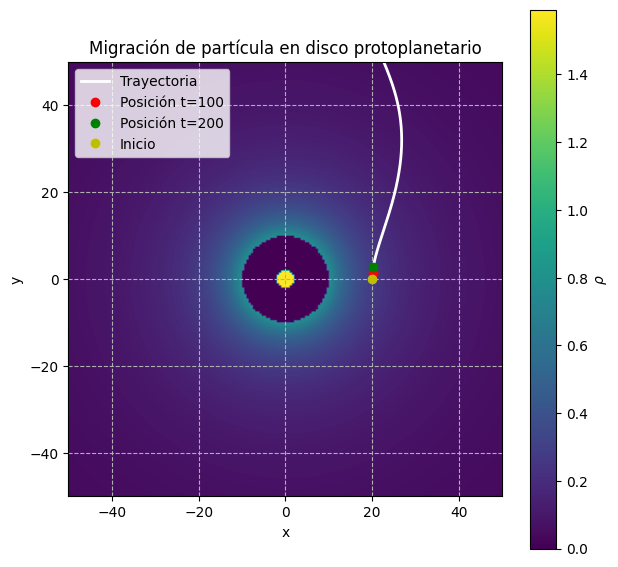

In [18]:
r_init = 20.0
G = 4 * np.pi**2  # en unidades de AU³/(M_sun*yr²)
#v_circ = np.sqrt(G * Mass_star / r_init)


from ode_solvers import rk4_method_second_order_2D

t0 = 0
tf = 40.0
h = 0.01

r0 = (20.0, 0.0)
v0 = (0.0, 1.4 )

v0_gas = 1.0  
r0_gas = 50.0   
alpha = 0.5 
gamma = 0.1  


t, r, v = rk4_method_second_order_2D(
    second_law,
    t0=t0,
    tf=tf,
    r0=r0,
    v0=v0,
    h=h
)

# -------------------------
# Gráfico
# -------------------------

plt.figure(figsize=(7,7))

# fondo: densidad estrella + disco
plt.imshow(
    rho_star + rho_disk,
    extent=[-L, L, -L, L],
    origin='lower',
    cmap='viridis'
)

plt.colorbar(label=r'$\rho$')

# trayectoria
plt.plot(
    r[:,0],
    r[:,1],
    color='white',
    lw=2,
    label='Trayectoria'
)

# puntos en tiempos específicos
plt.plot(r[100,0], r[100,1], 'ro', label='Posición t=100')
plt.plot(r[200,0], r[200,1], 'go', label='Posición t=200')

# punto inicial
plt.plot(r[0,0], r[0,1], 'yo', label='Inicio')

plt.xlabel('x')
plt.ylabel('y')

plt.title('Migración de partícula en disco protoplanetario')

plt.xlim(-50,50)
plt.ylim(-50,50)

plt.grid(True, ls='--')
plt.legend()

plt.show()

ahora con solve_ivp de SciPy

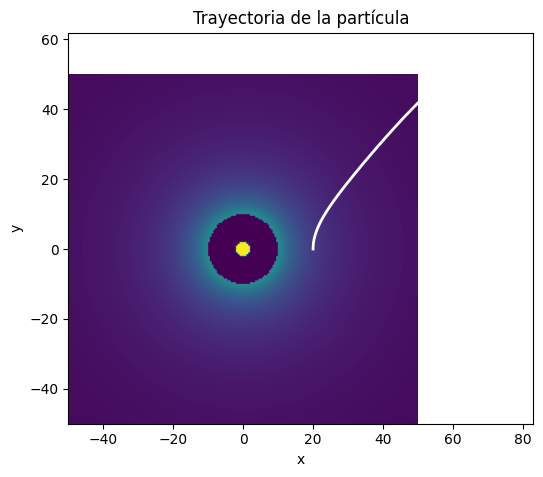

In [13]:
def second_law_newton(t, y):

    x, y_pos, vx, vy = y

    gx_val, gy_val = g(x, y_pos)

    return [
        vx,      # dx/dt
        vy,      # dy/dt
        gx_val,  # dvx/dt
        gy_val   # dvy/dt
    ]


x0 = 20
y0 = 0

vx0 = 0
vy0 = 1.4   # velocidad orbital aproximada

y0_vec = [x0, y0, vx0, vy0]


from scipy.integrate import solve_ivp

t0 = 0
tf = 40

sol = solve_ivp(
    second_law_newton,
    [t0, tf],
    y0_vec,
    method="RK45",
    max_step=0.01
)

x = sol.y[0]
y = sol.y[1]

plt.figure(figsize=(6,6))

plt.imshow(rho_star + rho_disk,
           extent=[-L, L, -L, L],
           origin="lower",
           cmap="viridis")

plt.plot(x, y, color="white", lw=2)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Trayectoria de la partícula")

plt.show()


esto creo yo q es buena señal

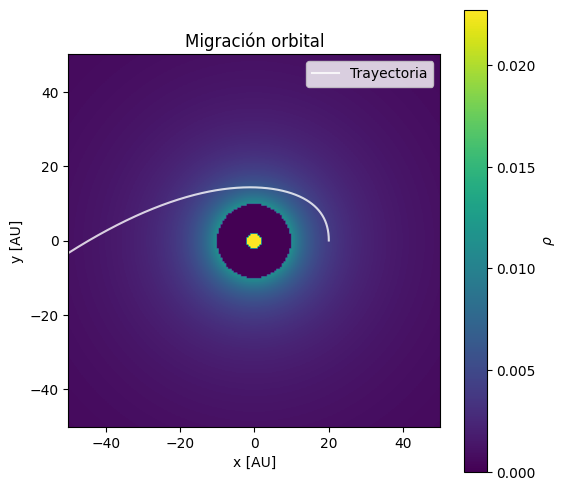

In [ ]:
# velocidad circular kepleriana en la posicion inicial (para orbita casi circular)
r_init = 20.0
v_circ = np.sqrt(G * Mass_star / r_init)

t, r_sol, v_sol = rk4_method_second_order_2D(
    second_law, t0=0, tf=100, r0=(r_init, 0.0), v0=(0.0, v_circ), h=0.01
)

plt.figure(figsize=(6,6))
plt.imshow(rho_star + rho_disk, extent=[-L, L, -L, L], origin='lower', cmap='viridis')
plt.plot(r_sol[:, 0], r_sol[:, 1], 'w-', alpha=0.8, label='Trayectoria')
plt.colorbar(label=r'$\rho$')
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Migración orbital')
plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.legend()
plt.show()

eso de arriba no se como funciono * **se le sale el cerebro por el oido derecho** *

tratando de ver q cosas estaban nada q verientas

In [ ]:
# Verificar que g apunta hacia el centro en (20, 0)
gx_test, gy_test = g(20.0, 0.0)
print(f"g en (20, 0): gx={gx_test:.4f}, gy={gy_test:.4f}")
print(f"Debería ser: gx negativo (apunta hacia x=0), gy~0")

# Verificar magnitud vs velocidad circular esperada
g_mag = np.sqrt(gx_test**2 + gy_test**2)
g_esperado = G * Mass_star / 20.0**2
print(f"Magnitud g calculada: {g_mag:.6f}")
print(f"Magnitud g esperada (GM/r²): {g_esperado:.4f}")

g en (20, 0): gx=-95.4450, gy=2.4556
Debería ser: gx negativo (apunta hacia x=0), gy~0
Magnitud g calculada: 95.476606
Magnitud g esperada (GM/r²): 1.9739


In [ ]:
print(f"Período orbital estimado: {2*np.pi * np.sqrt(r_init**3 / (G * Mass_star)):.2f} años")
print(f"Posición final: x={r_sol[-1,0]:.2f}, y={r_sol[-1,1]:.2f}")
print(f"Radio final: {np.sqrt(r_sol[-1,0]**2 + r_sol[-1,1]**2):.2f} AU")
print(f"Radio inicial: {np.sqrt(r_sol[0,0]**2 + r_sol[0,1]**2):.2f} AU")

Período orbital estimado: 20.00 años
Posición final: x=-1380.38, y=-2390.23
Radio final: 2760.19 AU
Radio inicial: 20.00 AU


In [ ]:
dx_au = 2*L / (N-1)
masa_total = np.sum(rho_star + rho_disk) * dx_au**2
print(f"Masa total en la malla: {masa_total:.4f} M_sol")
print(f"Debería ser ~{Mass_star:.1f} M_sol")
print(f"Factor de escala necesario: {Mass_star / masa_total:.6f}")

Masa total en la malla: 20.0000 M_sol
Debería ser ~20.0 M_sol
Factor de escala necesario: 0.999998


In [ ]:
gx_test, gy_test = g(20.0, 0.0)
g_mag = np.sqrt(gx_test**2 + gy_test**2)
g_esperado = G * Mass_star / 20.0**2
print(f"g calculada: {g_mag:.6f}")
print(f"g esperada:  {g_esperado:.6f}")

g calculada: 95.476606
g esperada:  1.973921
